In [1]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
import os
import sys
from tqdm import tqdm, trange

from IPython.display import Image, display

import imageio
import cairosvg
import tempfile
import os
from IPython.display import Image, display

sys.path.append("../../")
import biked_commons
from biked_commons.rendering import rendering, animation

from biked_commons.data_loading import data_loading
from biked_commons.conditioning import conditioning
from biked_commons.design_evaluation import design_evaluation

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


Using java as the Java binary


c:\Users\Lyler\mambaforge\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = data_loading.load_bike_bench_train()

In [3]:
data_variance = torch.tensor(data.var().values, device=device, dtype=torch.float32)
min_values = torch.tensor(data.min().values, device=device, dtype=torch.float32)
max_values = torch.tensor(data.max().values, device=device, dtype=torch.float32)

In [4]:
evaluators = [design_evaluation.AestheticsEvaluator(mode="Text", batch_size=64, device=device), design_evaluation.ErgonomicsEvaluator(device=device, constraints_only=True), design_evaluation.ValidationEvaluator(device=device)]
evaluator, requirement_names, requirement_types = design_evaluation.construct_tensor_evaluator(evaluators, data.columns)
rider_condition = conditioning.sample_riders(1, split="test")
condition = {"Text": ["Sporty jet-black racing bike"], "Rider": rider_condition}

In [5]:
with torch.no_grad():
    baseline_scores = evaluator(torch.tensor(data.values, dtype=torch.float32, device=device), condition)
score_std = baseline_scores.std(dim=0)

In [32]:
data_gd = torch.tensor(data.iloc[1:2].values, dtype=torch.float32, device=device, requires_grad=True)

all_steps = [data_gd.detach().clone()]
all_losses = []
for i in tqdm(range(1500)):
    scores = evaluator(data_gd, condition)
    scores = scores / score_std  # Normalize scores by standard deviation

    objective_scores = scores[:, np.array(requirement_types) == 1]
    aggregate_objective_score = objective_scores.mean(dim=1)

    constraint_scores = scores[:, np.array(requirement_types) == 0]
    thresholded_constraint_scores = torch.clamp(constraint_scores, min=0)
    aggregate_constraint_score = thresholded_constraint_scores.mean(dim=1)

    constraint_weight=10
    total_score = aggregate_objective_score + aggregate_constraint_score * constraint_weight

    all_losses.append(total_score.item())
    total_score.backward()

    with torch.no_grad():
        #exit if data_gd is not changing
        if data_gd.grad is None or torch.all(data_gd.grad.abs() < 1e-6):
            print("Gradient is zero, stopping optimization.")
            break
        data_gd -= 0.3 * data_gd.grad * data_variance #equivalent to gd on the normalized data
        # data_gd = torch.clamp(data_gd, min_values, max_values)
        

    data_gd.requires_grad_()
    data_gd.grad = None

    all_steps.append(data_gd.detach().clone())

all_steps_tensor = torch.stack(all_steps, dim=0).cpu()  # shape: (steps, 1, features)
steps_df = pd.DataFrame(all_steps_tensor.squeeze(1).numpy(), columns=data.columns)

100%|██████████| 1500/1500 [02:25<00:00, 10.32it/s]


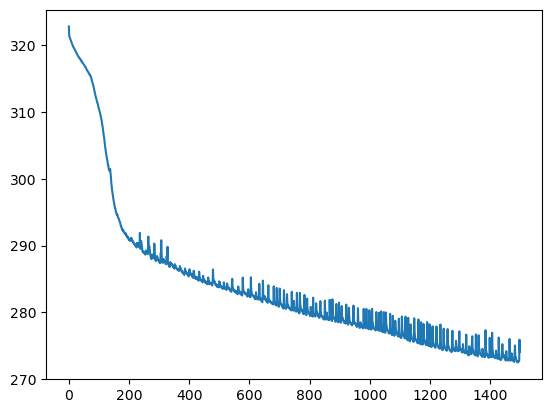

In [33]:
#plot all losses
import matplotlib.pyplot as plt
plt.plot(all_losses)

In [34]:
steps_df[["FIRST color R_RGB", "FIRST color G_RGB", "FIRST color B_RGB"]]

,FIRST color R_RGB,FIRST color G_RGB,FIRST color B_RGB
0,0.000000,0.000000,102.000000
1,158.551483,145.768585,93.702232
2,162.259995,160.190460,102.888405
3,164.971924,171.865204,110.278061
4,165.909515,182.344162,117.718079
...,...,...,...
1496,175.426773,86.595261,76.667435
1497,201.249664,52.046768,49.850296
1498,181.376648,70.097885,82.102600
1499,190.889725,35.737621,61.585243


In [35]:
steps_df

,CS textfield,BB textfield,Stack,Head angle,Head tube length textfield,Seat stay junction0,Seat tube length,Seat angle,DT Length,FORK0R,...,Handlebar style OHCLASS: 2,Stem kind OHCLASS: 0,Stem kind OHCLASS: 1,Stem kind OHCLASS: 2,Fork type OHCLASS: 0,Fork type OHCLASS: 1,Fork type OHCLASS: 2,Seat tube type OHCLASS: 0,Seat tube type OHCLASS: 1,Seat tube type OHCLASS: 2
0,796.940002,-3.000000,363.410645,39.000000,181.199997,36.000000,567.000000,37.000000,1243.389038,45.000000,...,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,1.000000,0.000000
1,796.909546,-2.299165,362.377319,39.039539,180.642700,36.308754,572.102478,37.175186,1244.118896,44.720840,...,-0.006122,1.0,-0.000639,-0.005057,0.008972,1.000000,-0.001884,-0.00227,1.000000,0.006452
2,795.632812,-1.964273,360.623657,39.041660,179.086868,37.128685,573.639221,37.390308,1245.008423,44.758091,...,-0.006122,1.0,-0.000639,-0.005057,0.007199,1.000014,-0.001884,-0.00227,0.999964,0.011477
3,794.011780,-1.028793,358.972565,39.039204,178.071259,37.764343,556.943787,37.538170,1246.130737,44.825077,...,-0.006122,1.0,-0.000639,-0.005057,0.005211,1.000014,-0.001884,-0.00227,0.999893,0.017020
4,792.609863,0.083135,357.336151,39.035538,177.333405,38.360332,556.330566,37.705994,1247.038208,44.860870,...,-0.006122,1.0,-0.000639,-0.005057,-0.002392,1.000014,-0.001884,-0.00227,0.999791,0.022433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1496,550.601807,-226.569305,158.219040,49.741898,523.997253,1416.225586,2.265167,16.404909,2238.492432,136.975769,...,-0.006122,1.0,-0.000639,-0.005057,-0.002392,1.000014,-0.001884,-0.00227,-0.001047,0.953087
1497,545.077637,-225.725204,158.130249,49.901325,523.853943,1417.337646,4.897305,16.311209,2235.571533,136.717346,...,-0.006122,1.0,-0.000639,-0.005057,-0.002392,1.000014,-0.001884,-0.00227,-0.001047,0.953087
1498,547.669312,-226.505890,156.610535,49.869076,524.245789,1417.330566,-1.292371,16.317421,2236.174316,136.838058,...,-0.006122,1.0,-0.000639,-0.005057,-0.002392,1.000014,-0.001884,-0.00227,-0.001047,0.953087
1499,543.754639,-224.326508,154.692291,49.983025,525.982361,1418.336548,198.232315,16.642124,2235.937988,136.782852,...,-0.006122,1.0,-0.000639,-0.005057,-0.002392,1.000014,-0.001884,-0.00227,-0.001047,0.953087


In [36]:
#score the last step
last_scores = evaluator(all_steps[-1], condition)


In [37]:
last_scores

tensor([[ 3.2755e-01, -2.1961e+00,  1.1356e+00, -2.4802e+00, -3.2556e-01,
         -8.4031e-01, -4.9760e-01,  7.6746e+01, -4.0157e+01, -1.3028e+02,
         -1.6316e+02, -8.1802e+01,  2.5723e+00, -1.5457e+02, -5.2261e+02,
          2.2125e-01, -2.0564e+02, -7.8010e+02, -1.3581e+03, -2.0859e+00,
         -2.4735e+03, -1.0000e+09, -4.5814e+06, -3.8696e+02, -4.1224e+02,
         -2.5227e-01,  0.0000e+00,  1.2670e-01,  5.8496e+01,  3.1034e-01,
         -3.9690e+01, -1.9512e+01]], device='cuda:0', grad_fn=<CopySlices>)

In [16]:
requirement_names

['Cosine Distance to Text',
 'Arm Too Long for Bike',
 'Saddle Too Far From Handle',
 'Torso Too Long for Bike',
 'Saddle Too Far From Crank',
 'Upper Leg Too Long for Bike',
 'Lower Leg Too Long for Bike',
 'Saddle height too small',
 'Saddle too short',
 'Head angle over limit',
 'Seat angle over limit',
 'Seat post too short',
 'Wheel inner diameter too small',
 'Seat tube extension longer than seat tube',
 'Head tube upper extension and lower extension overlap',
 'Strictly postive parameter is negative',
 'Chain stay smaller than rear wheel radius',
 'Chain stay shorter than BB drop',
 'Seat stay smaller than rear wheel radius',
 'Seat Tube Intersects Rear Wheel2',
 "Down tube can't reach head tube",
 'Rear wheel cutout severs seat tube',
 'Foot intersects front wheel',
 'Crank hits ground in lowest position',
 'RGB value greater than 255',
 'Chain stays intersect',
 'Tube wall thickness exceeds radius',
 'Seat tube inner diameter thinner than seat post outer diameter',
 'Down tube

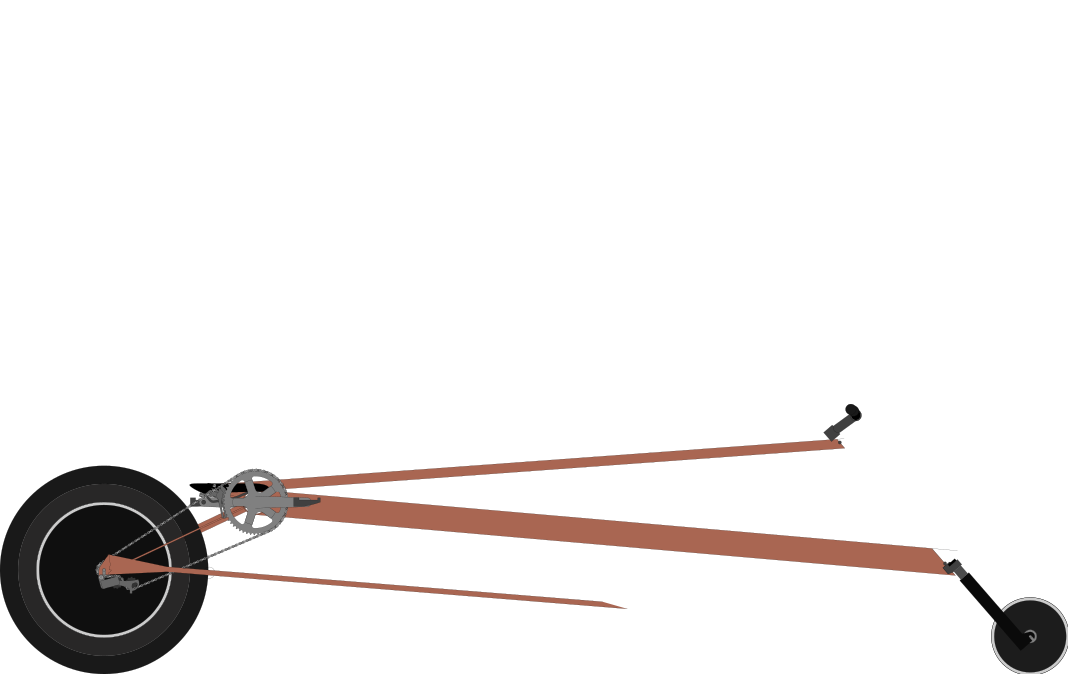

In [38]:
last_step = steps_df.iloc[-1]

renderer = rendering.RenderingEngine(number_rendering_servers = 1, server_init_timeout_seconds=120)

res = renderer.render_clip(last_step)
svg = res.image_bytes
from IPython.display import SVG, display
display(SVG(svg))

In [11]:
# steps_subset = steps_df.iloc[::100, :].reset_index(drop=True)
# mp4 = animation.render_to_animation(steps_subset, fps=10, mp4_filename="aesthetics.mp4", rider_dims = None)

In [12]:
# from IPython.display import Video
# mp4.seek(0)
# display(Video(data=mp4.read(), embed=True))


In [13]:
# with open("output_bike.bcad", "w", encoding="utf-8") as f:
#     f.write(res.xml_file)